In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed


<bound method NDFrame.tail of Price            Close        High         Low        Open     Volume  \
Date                                                                    
2000-01-21   90.739304   91.406793   90.503719   91.406793    6244800   
2000-01-24   88.167480   91.622719   87.578519   91.504927    7896900   
2000-01-25   89.168739   89.168739   87.323327   88.275481    9942500   
2000-01-26   88.462013   88.923366   88.010476   88.579806    5158100   
2000-01-27   88.108620   89.345439   86.773641   89.109854   10922700   
...                ...         ...         ...         ...        ...   
2026-03-16  667.207886  670.239584  665.303054  666.559632   82023100   
2026-03-17  668.963013  672.603096  667.876016  670.558691   87128000   
2026-03-18  659.628540  667.895940  659.389203  666.539658   82062600   
2026-03-19  658.002991  661.174323  653.385596  655.180681  111272500   
2026-03-20  648.570007  656.690002  644.719971  656.510010  138283514   

Price             RS

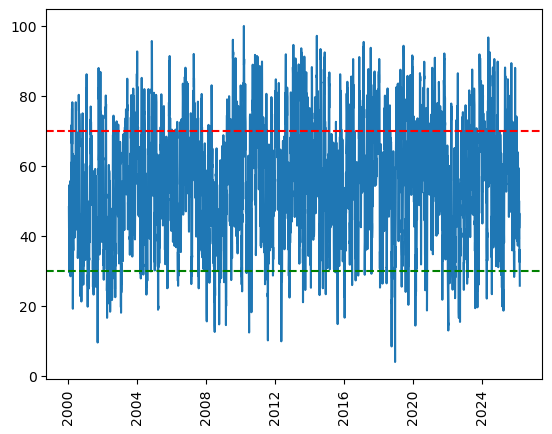

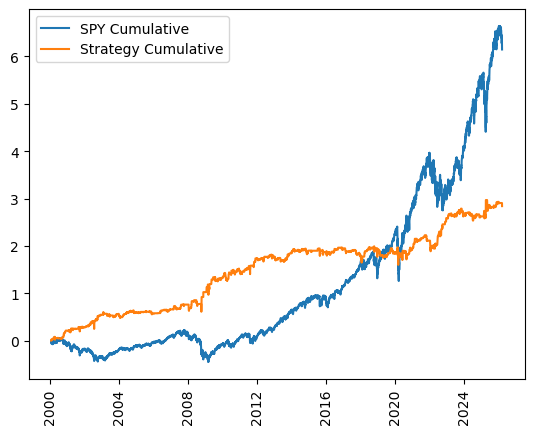

In [3]:
TICKER = 'SPY'
RSI_LENGTH = 14
OVERBOUGHT = 70
OVERSOLD = 30
LOOKBACK = 10000

def get_data(ticker=TICKER):
    df = yf.download(ticker, start='2000-01-01')
    df.columns = df.columns.get_level_values(0)

    #only returns the subset of data you are interested in
    return df.iloc[-LOOKBACK:, :]

def add_RSI(df, length=RSI_LENGTH):
    
    price_change = df['Close'].diff() #calculating delta

    #separate gains and losses
    gain = price_change.where(price_change > 0, 0 )
    loss = -price_change.where(price_change < 0, 0 )

    #average gains and losses
    avg_gain = gain.rolling(window=length).mean()
    avg_loss = loss.rolling(window=length).mean()

    #calculate rsi
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df['RSI'] = rsi


    #plotting the graph
    plt.plot(df['RSI'])
    plt.axhline(OVERBOUGHT, color='red', linestyle='--')
    plt.axhline(OVERSOLD, color='green', linestyle='--')
    plt.xticks(rotation='vertical')

    return df.dropna()


def add_strategy(df, overbought=OVERBOUGHT, oversold=OVERSOLD):
    
    df['Strategy'] = 0
    df['Strategy'] = np.where(df['RSI'] > overbought, -1,
                     np.where(df['RSI'] < oversold, 1, 0))
    df['Strategy'] = df['Strategy'].shift(1) #shifting back to see the signal

    return df

def test_strategy(df):
    df['Asset_Returns'] = (1+df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = ( 1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1

    #plotting the strategy
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.xticks(rotation='vertical')

    return df

def main():
    df = get_data()
    df = add_RSI(df)
    df = add_strategy(df)
    df = test_strategy(df)

    return df

df = main()
df.tail

In [4]:
df['Strategy'].value_counts()

Strategy
 0.0    4997
-1.0    1234
 1.0     348
Name: count, dtype: int64